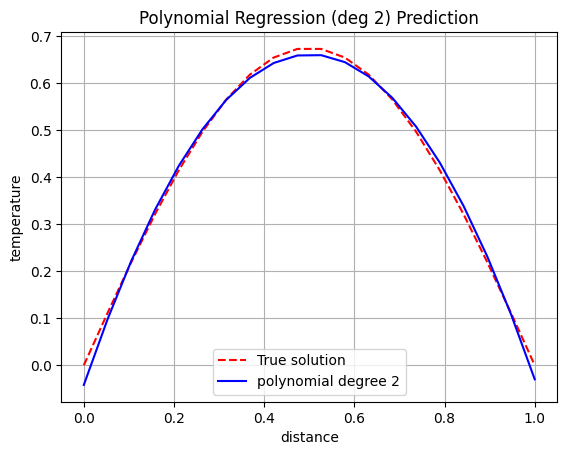

In [82]:
# polynomial regression for heat conduction equation

import numpy as np
import matplotlib.pyplot as plt

#specify the values 
k=3 
q=20
L=1

T=q*(L**2)/(k*np.pi**2) #the constant value

N=30 #no. of features
x=np.sort(np.random.rand(N))
#print(f"value of input data-\n {x}")

T_x=T*np.sin(np.pi*x/L) #derived T(x)

noise=0 #noise
T_noisy=T_x+noise*T*np.random.rand(N) #generating noisy data

##########
#This is the splitting of data, 80% to train and 20% testing
##########

index=np.random.permutation(N)
train=int(0.8*N) #splitting

train_data=index[:train] #train from one end to train part
test_data=index[train:] #rest of data

#the split data is then substituted 
x_train=x[train_data]         
y_train=T_noisy[train_data]

x_test=x[test_data]
y_test=T_noisy[test_data]

#initialize the Xth vector
def poly_basis(x,degree): 
    return np.vstack([x**i for i in range(degree+1)]).T #vector transposed
    
degree=2 #degree, 2nd degree works great
X_train=poly_basis(x_train, degree)
w=np.linalg.inv(X_train.T@X_train)@(X_train.T@y_train) # weight, w=[(XTX)^-1(XTy)]

def predict_polynomial(x,w): #final assembly X.w
    X=poly_basis(x,len(w)-1)
    return X@w

y_train_pred=predict_polynomial(x_train,w) # y_hat or predicted
y_test_pred=predict_polynomial(x_test,w)

x_plot=np.linspace(0,1,20)
y_plot_pred=predict_polynomial(x_plot,w) #predicted
y_plot_true=T*np.sin(np.pi*x_plot/L) #real value

#plotting the data
plt.plot(x_plot,y_plot_true,color="red",linestyle="--",label="True solution")
plt.plot(x_plot,y_plot_pred,color="blue",label=f"polynomial degree {degree}")
plt.xlabel("distance")
plt.ylabel("temperature")
plt.title(f"Polynomial Regression (deg {degree}) Prediction")
plt.legend()
plt.grid(True)
#plt.savefig(r"C:\Users\Apoorva Singh\OneDrive - Amity University\Desktop\Deep learning\Ass2\noise0.1_deg15.png",dpi=600)
plt.show()